In [36]:
import json
import numpy as np
from self_learning_VNS import *
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


In [53]:
coverage_area_num = 9
mode = 'RC'
operational_node_num = 10
with open(f'./instances/{coverage_area_num}/instance_{mode}_{coverage_area_num}_{operational_node_num}.json', 'r') as f:
    instance_data = json.load(f)

area_center = instance_data['area_center']
area_type = instance_data['area_type']
area_polygon = instance_data['area_polygon']
coverage_points = instance_data['coverage_points']
total_stop_nodes = instance_data['total_stop_nodes']
# convert keys from str to int
area_center = {int(k): v for k, v in area_center.items()}
area_type = {int(k): v for k, v in area_type.items()}
area_polygon = {int(k): np.array([pt for pt in v]) for k, v in area_polygon.items()}
coverage_points = {int(k): np.array([pt for pt in v]) for k, v in coverage_points.items()}
base = np.array([[0,0], [100,100]])
S = set([i for i in range(len(area_center))])
stop_nodes = total_stop_nodes
# coverage_points = {0: coverage_points1, 1: coverage_points2, 2:np.array([[5, 4.5]])}
# coverage_points_num = {0: len(coverage_points[0]), 1: len(coverage_points[1]), 2: len(coverage_points[2])}
S_node = set([2])
# for key in coverage_points:
#     coverage_points[key] = np.array(sort_points(coverage_points[key]))
N_s = {}
N_coord = np.vstack((base[0], stop_nodes))
N_p = [i for i in range(1, len(N_coord))]
for s in S:
    N_s[s] = [len(N_coord)]
    N_coord = np.vstack((N_coord, coverage_points[s]))
    N_s[s].append(len(N_coord))
N_coord = np.vstack((N_coord, base[1]))
N = [i for i in range(len(N_coord))]
ti_s = [0] * len(N)
for s in S:
    N_s[s] = [i for i in range(N_s[s][0], N_s[s][1])]
N1 = [0] + N_p
N2 = N_p + [len(N_coord)-1]
N3 = [0] + N_p + [len(N_coord)-1]
RTD = 0.1
LTD = 0.1
M = 90
V_d = 40
V_k = 20
V = [1,2,3,4,5]
TK_min = {i:0 for i in N3}
TK_max = {i:10 for i in N3}
TD_min = [0, 0, 0]
TD_max = [3, 3, 3]

# 计算点之间的距离
def distance(p1, p2):
    return np.linalg.norm(p1 - p2)
# 计算点之间的距离矩阵
def distance_matrix(points):
    n = len(points)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = distance(points[i], points[j])
            dist_matrix[i][j] = dist
            dist_matrix[j][i] = dist
    return dist_matrix

dij = distance_matrix(N_coord)
tij_k = dij / V_k
tij_d = dij / V_d

In [54]:
with open(f'result_{mode}_{coverage_area_num}_{operational_node_num}.json', 'r') as f:
    result_data = json.load(f)

In [55]:
result_data['drone_route']

{'1': {'1': [8, 28, 27, 29, 30, 19],
  '2': [2, 23, 8],
  '3': [19, 73, 74, 75, 76, 92],
  '4': [3, 53, 54, 52, 51, 49, 50, 2]},
 '2': {'1': [19, 69, 70, 71, 72, 92],
  '2': [8, 32, 31, 33, 34, 19],
  '3': [3, 57, 58, 56, 55, 8]},
 '3': {'1': [12, 91, 8],
  '2': [3, 47, 48, 12],
  '3': [0, 24, 3],
  '4': [19, 77, 78, 80, 79, 81, 82, 92],
  '5': [8, 36, 35, 37, 38, 19]},
 '4': {'1': [13, 25, 26, 19],
  '2': [14, 67, 68, 13],
  '3': [19, 84, 83, 86, 85, 92],
  '4': [8, 39, 40, 14],
  '5': [3, 59, 60, 8]},
 '5': {'1': [13, 90, 89, 19],
  '2': [19, 88, 87, 92],
  '3': [8, 45, 46, 44, 43, 41, 42, 13],
  '4': [3, 65, 66, 64, 63, 61, 62, 8]}}

In [56]:

# 将key从str转换为int
result_data['drone_route'] = {int(k): v for k, v in result_data['drone_route'].items()}
for k in result_data['drone_route'].keys():
    result_data['drone_route'][k] = {int(k): v for k, v in result_data['drone_route'][k].items()}

In [57]:
total_time = get_total_time(result_data['drone_route'], result_data['truck_route'], tij_k, tij_d, V, [0]*500, LTD, RTD)

In [58]:
total_time[1]

{0: 0,
 3: 2.6831182706178978,
 12: 3.519514373685791,
 2: 4.271782424545154,
 8: 4.943481481147983,
 14: 5.803318894360234,
 13: 6.053318894360233,
 19: 7.085900566336637,
 92: 9.713120759788396}

In [59]:
drone_sortie_total_times = {}
for drone_id in total_time[2].keys():
    drone_sortie_total_times[drone_id] = {}
    for sortie_id in total_time[2][drone_id].keys():
        retrieval_node = result_data['drone_route'][drone_id][sortie_id][-1]
        # idx_truck = result_data['truck_route'].index(retrieval_node)
        truck_arrival_time = total_time[1][retrieval_node]
        drone_sortie_total_times[drone_id][sortie_id] = max(total_time[2][drone_id][sortie_id][-1], truck_arrival_time) - total_time[2][drone_id][sortie_id][0]+0.2

In [60]:
drone_sortie_total_times

{1: {4: 1.6886641539272558,
  2: 0.67169905660283,
  1: 2.1424190851886546,
  3: 2.62722019345176},
 2: {3: 2.3603632105300854, 2: 2.1424190851886546, 1: 2.62722019345176},
 3: {3: 2.783118270617898,
  2: 0.8363961030678928,
  1: 1.4734767398877586,
  5: 2.092909452763088,
  4: 2.62722019345176},
 4: {5: 2.3603632105300854,
  4: 0.8598374132122515,
  2: 0.5901387818865993,
  1: 0.885272786391132,
  3: 2.4343902971504328},
 5: {4: 2.3603632105300854,
  3: 1.1098374132122506,
  1: 1.0325816719764045,
  2: 2.62722019345176}}

In [61]:
tij_d[1,2]

0.16770509831248423

In [62]:
result_data['drone_route']

{1: {1: [8, 28, 27, 29, 30, 19],
  2: [2, 23, 8],
  3: [19, 73, 74, 75, 76, 92],
  4: [3, 53, 54, 52, 51, 49, 50, 2]},
 2: {1: [19, 69, 70, 71, 72, 92],
  2: [8, 32, 31, 33, 34, 19],
  3: [3, 57, 58, 56, 55, 8]},
 3: {1: [12, 91, 8],
  2: [3, 47, 48, 12],
  3: [0, 24, 3],
  4: [19, 77, 78, 80, 79, 81, 82, 92],
  5: [8, 36, 35, 37, 38, 19]},
 4: {1: [13, 25, 26, 19],
  2: [14, 67, 68, 13],
  3: [19, 84, 83, 86, 85, 92],
  4: [8, 39, 40, 14],
  5: [3, 59, 60, 8]},
 5: {1: [13, 90, 89, 19],
  2: [19, 88, 87, 92],
  3: [8, 45, 46, 44, 43, 41, 42, 13],
  4: [3, 65, 66, 64, 63, 61, 62, 8]}}

In [63]:
drone_sortie_coverage_time = {}
for drone_id in result_data['drone_route'].keys():
    drone_sortie_coverage_time[drone_id] = {}
    for sortie_id in result_data['drone_route'][drone_id].keys():
        sortie_route = result_data['drone_route'][drone_id][sortie_id]
        coverage_time = 0
        for node_idx in range(len(sortie_route)-1):
            coverage_time += tij_d[sortie_route[node_idx], sortie_route[node_idx+1]]
        drone_sortie_coverage_time[drone_id][sortie_id] = coverage_time

In [64]:
drone_sortie_coverage_time

{1: {1: 0.9036204133257023,
  2: 0.4212756921743879,
  3: 2.1516547984941825,
  4: 0.9388548949268443},
 2: {1: 2.1607222588876462, 2: 0.955744216590614, 3: 1.1012905753253608},
 3: {1: 1.2734767398877582,
  2: 0.3220014863438969,
  3: 1.4799915248857336,
  4: 2.40997937197506,
  5: 0.9819710767541011},
 4: {1: 0.6852727863911319,
  2: 0.39013878188659973,
  3: 2.1241341361987374,
  4: 0.5828530143746943,
  5: 0.8264332439654294},
 5: {1: 0.644261542019948,
  2: 2.079251485398187,
  3: 0.734910523530974,
  4: 1.0621702797108596}}

In [65]:
drone_sortie_coverage_ratio = {}
drone_sortie_operational_ratio = {}
drone_sortie_waiting_ratio = {}
for drone_id in drone_sortie_total_times.keys():
    drone_sortie_coverage_ratio[drone_id] = {}
    drone_sortie_operational_ratio[drone_id] = {}
    drone_sortie_waiting_ratio[drone_id] = {}
    for sortie_id in drone_sortie_total_times[drone_id].keys():
        coverage_time = drone_sortie_coverage_time[drone_id][sortie_id]
        total_time_val = drone_sortie_total_times[drone_id][sortie_id]
        drone_sortie_coverage_ratio[drone_id][sortie_id] = coverage_time / total_time_val
        drone_sortie_operational_ratio[drone_id][sortie_id] = 0.2 / total_time_val
        drone_sortie_waiting_ratio[drone_id][sortie_id] = (total_time_val - coverage_time - 0.2) / total_time_val

In [66]:
# get the mean value of all the ratio
count_num = 0
sum_coverage_ratio = 0
sum_waiting_ratio = 0
sum_operational_ratio = 0
for drone_id in drone_sortie_coverage_ratio.keys():
    for sortie_id in drone_sortie_coverage_ratio[drone_id].keys():
        sum_coverage_ratio += drone_sortie_coverage_ratio[drone_id][sortie_id]
        sum_waiting_ratio += drone_sortie_waiting_ratio[drone_id][sortie_id]
        sum_operational_ratio += drone_sortie_operational_ratio[drone_id][sortie_id]
        count_num += 1
mean_coverage_ratio = sum_coverage_ratio / count_num
mean_waiting_ratio = sum_waiting_ratio / count_num
mean_operational_ratio = sum_operational_ratio / count_num

In [67]:
composition = []
composition = composition + [mean_coverage_ratio, mean_waiting_ratio, mean_operational_ratio]

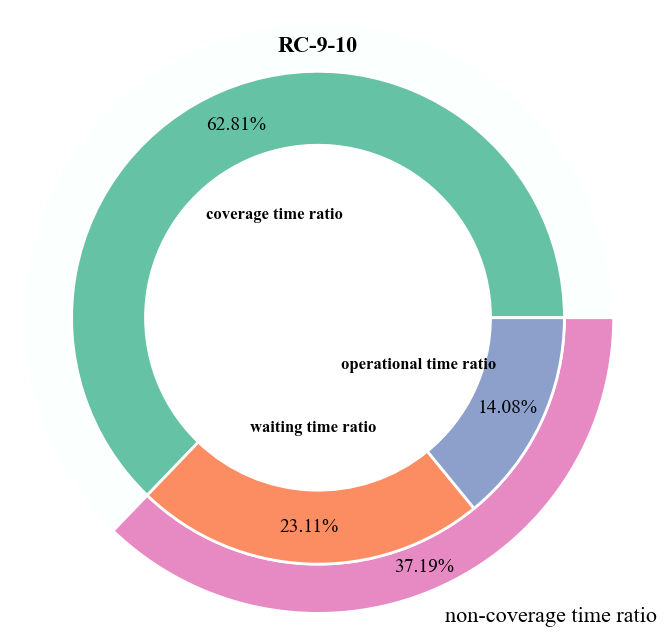

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
names = ['coverage time ratio', 'waiting time ratio', 'operational time ratio']
# composition = [0.6281, 0.2311, 0.1408]  # 原始比例
non_coverage_total = composition[1] + composition[2]  # non-coverage总和

# 外层圆环数据
outer_composition = [composition[0], non_coverage_total]
outer_names = ['', 'non-coverage time ratio']


# 绘制双层圆环图
fig, ax = plt.subplots(figsize=(8, 8))

# ---------- 外层圆环 ----------
outer_wedges, outer_texts = ax.pie(
    outer_composition,
    radius=1.2,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white', 'width': 0.2},
    colors=["#fbfffe", '#e78ac3'],
    labels=outer_names,
    textprops={'fontname': 'Times New Roman', 'fontsize': 16}
)

# ---------- 内层圆环（不直接显示labels，后续手动调整） ----------
inner_wedges, _ = ax.pie(
    composition,
    radius=1.0,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white', 'width': 0.3},
    colors=['#66c2a5', '#fc8d62', '#8da0cb'],
    # 先不传递labels，后续手动在圆环内部添加
)


# ---------- 手动添加内层标签（放在圆环内部） ----------
for i, (wedge, name) in enumerate(zip(inner_wedges, names)):
    # 计算每个扇区的中心角度
    theta = wedge.theta2 - (wedge.theta2 - wedge.theta1) / 2
    # 调整半径：让标签位于内层圆环的“环内”（半径=0.8左右，根据圆环厚度调整）
    x = 0.45 * np.cos(np.radians(theta))
    y = 0.45 * np.sin(np.radians(theta))
    # 添加标签（文字换行/缩小字体避免拥挤）
    plt.text(
        x, y, name,
        fontsize=12, ha='center', va='center',
        fontname='Times New Roman',
        wrap=True,  # 自动换行
        fontweight='bold'
    )


# ---------- 标注内层百分比（放在标签附近） ----------
for wedge, percent in zip(inner_wedges, composition):
    theta = wedge.theta2 - (wedge.theta2 - wedge.theta1) / 2
    # 百分比位置比标签稍向内/外（避免重叠）
    x = 0.85 * np.cos(np.radians(theta))
    y = 0.85 * np.sin(np.radians(theta))
    plt.text(
        x, y, f'{round(percent*100,2)}%',
        fontsize=14, ha='center', va='center',
        fontname='Times New Roman'
    )


# ---------- 外层non-coverage百分比 ----------
outer_percent = non_coverage_total * 100
for i, wedge in enumerate(outer_wedges):
    if outer_names[i] == 'non-coverage time ratio':
        theta = wedge.theta2 - (wedge.theta2 - wedge.theta1)/2
        x = 1.1 * np.cos(np.radians(theta))
        y = 1.1 * np.sin(np.radians(theta))
        plt.text(
            x, y, f'{round(outer_percent,2)}%',
            fontsize=14, ha='center', va='center',
            fontname='Times New Roman'
        )


# 中心白色圆圈
my_circle = plt.Circle((0, 0), 0.7, color='white')
ax.add_artist(my_circle)

# 标题
plt.text(
    0, 1.1, 'RC-9-10',
    fontsize=16, ha='center', va='center',
    fontname='Times New Roman', fontweight='bold'
)

plt.show()